# Exercises 10

## Exercise 10.1

I choose to simulate the first option:
1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

The code for the non-parallel genetic algorithm is already fully implemented in exercises 9. I just need to add parallelization, and migrations.

### Parallelization 

To add a simple non communicating parallelization one just need to add mpi in the code, and compile the code with `openmpi` or `opench`. To compile the code I used `openmpi` simply because I already had it installed.

In the program i also added comunication between threads using *broadcast*, *send* and *receve* (below is described how I used).

### Migrations

Every $N_\text{migr.} = 100$ generations I allow the migration, in the migration the best individual of each thread gets sent to another thread. This simulates the migration of individuals between continents, which increases the genetic variations.

To choose the migrations I generated a random vector of rank indexes, the order of this vector decided the migration between ranks: each rank sent the best individual to the following rank, while receiving from the previous. 
The random vector was generated by only the rank 0, while the order was broadcasted to all other ranks. Then each rank used a non blocking send and receive for the individuals.

The simulations were run for both migrations and non migrations with: 500 individuals, 2000 generations, the exponent of selection $p = 2 \mapsto 7$, and the probabilities: $p_\text{swap} = 0.001$ (applied 109 times, which cumulates to $p_\text{swap}^\text{(tot)} \approx 0.1$), $p_\text{shift} = 0.10$, $p_\text{permute} = 0.05$, $p_\text{invert} = 0.08$, $p_\text{cross.} = 0.65$;

## Documentation 

This exercises is fully documented: one can fine the [pdf version]() or the [web version]().

In [1]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from adjustText import adjust_text
import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

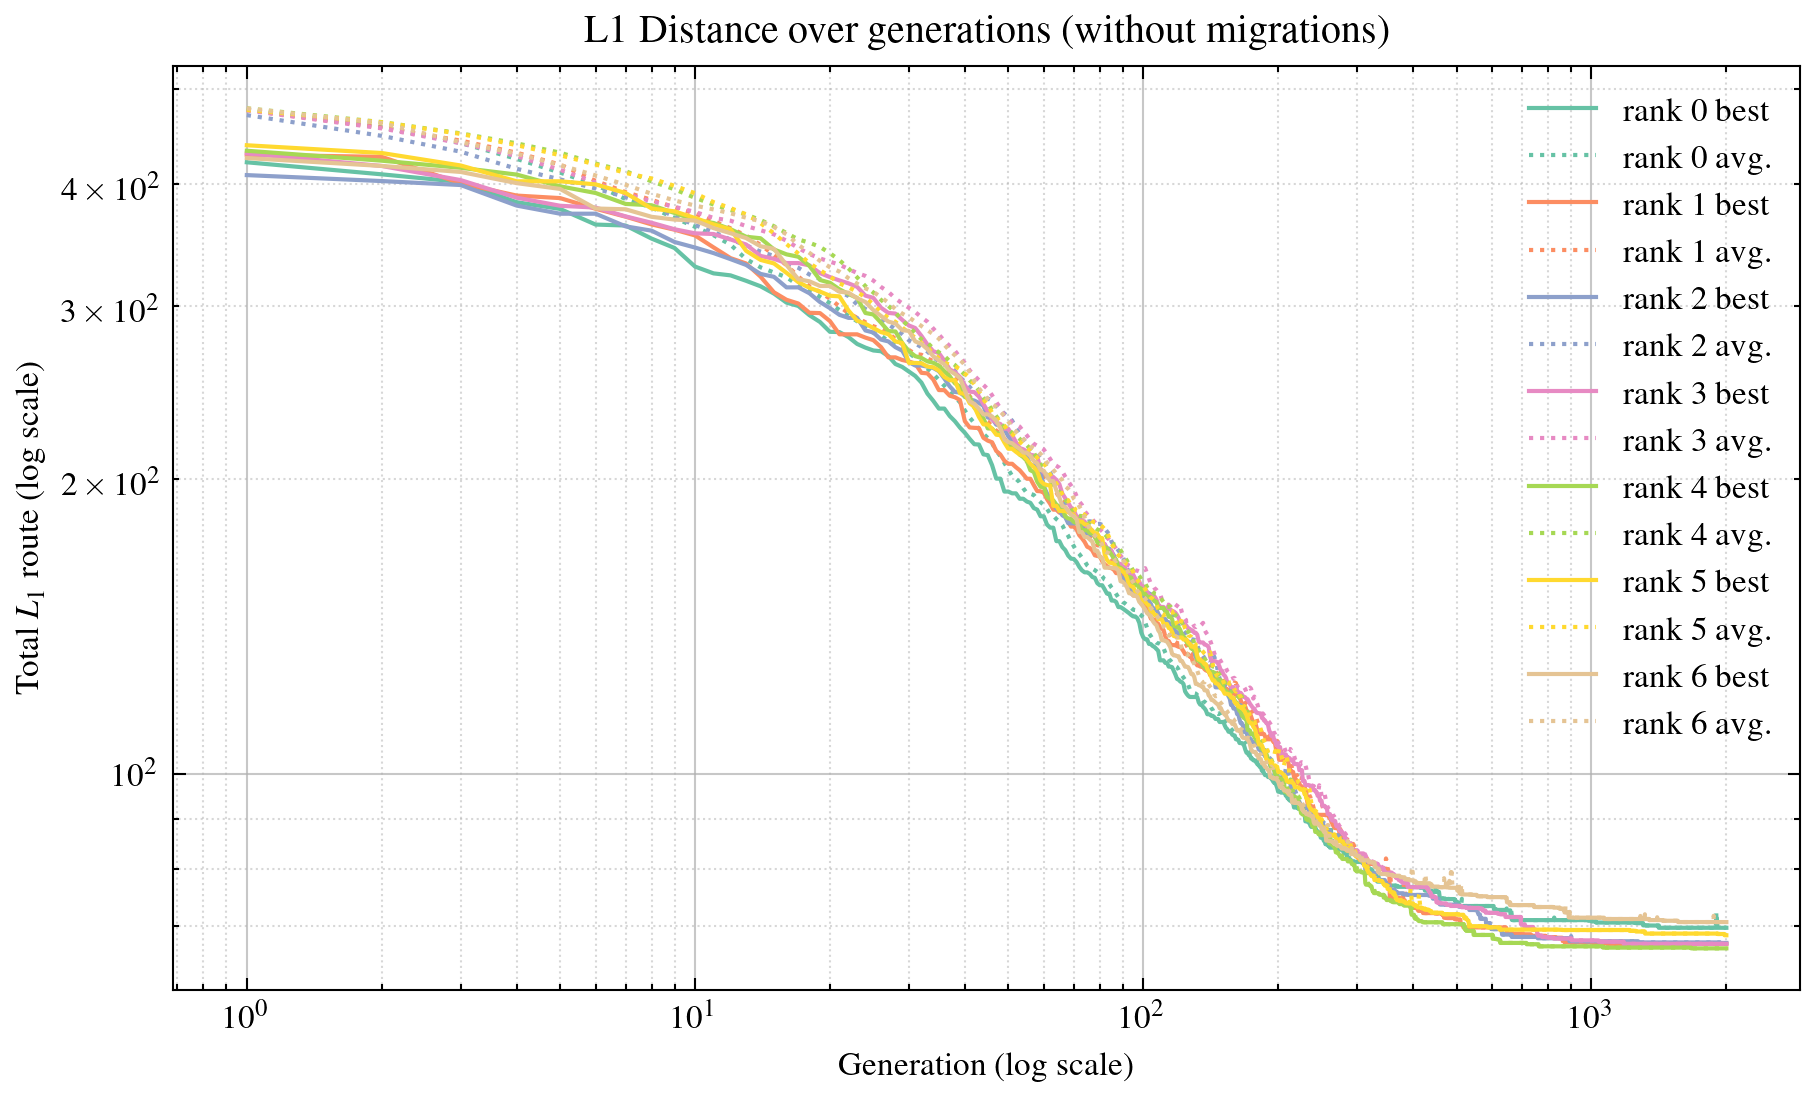

In [2]:
ranks = 7
min_no_migration = 1e12  # best route length over all ranks

fig = plt.figure(figsize=(7, 4))

for rank in range(ranks):
    data = np.loadtxt(f"./data_no_migrations/route_rank{rank}.dat", skiprows=1)

    if data[-1, 0] < min_no_migration:
        min_no_migration = data[-1, 0]

    x = np.arange(len(data)) + 1

    (line,) = plt.plot(x, data[:, 0], label=f"rank {rank} best")
    plt.plot(x, data[:, 1], label=f"rank {rank} avg.", ls=":", color=line.get_color())

# style
plt.legend()
plt.grid(which="major", alpha=0.7)
plt.grid(which="minor", alpha=0.5, ls=":")

plt.title("L1 Distance over generations (without migrations)")
plt.xlabel("Generation (log scale)")
plt.ylabel(r"Total $L_1$ route (log scale)")

plt.xscale("log")
plt.yscale("log")

plt.show()

We can see that the diffrent ranks have similar curves, but after 2000 generations each rank finds a different path length, which means that at least $N_\text{ranks} -1$ could improve their solutions.

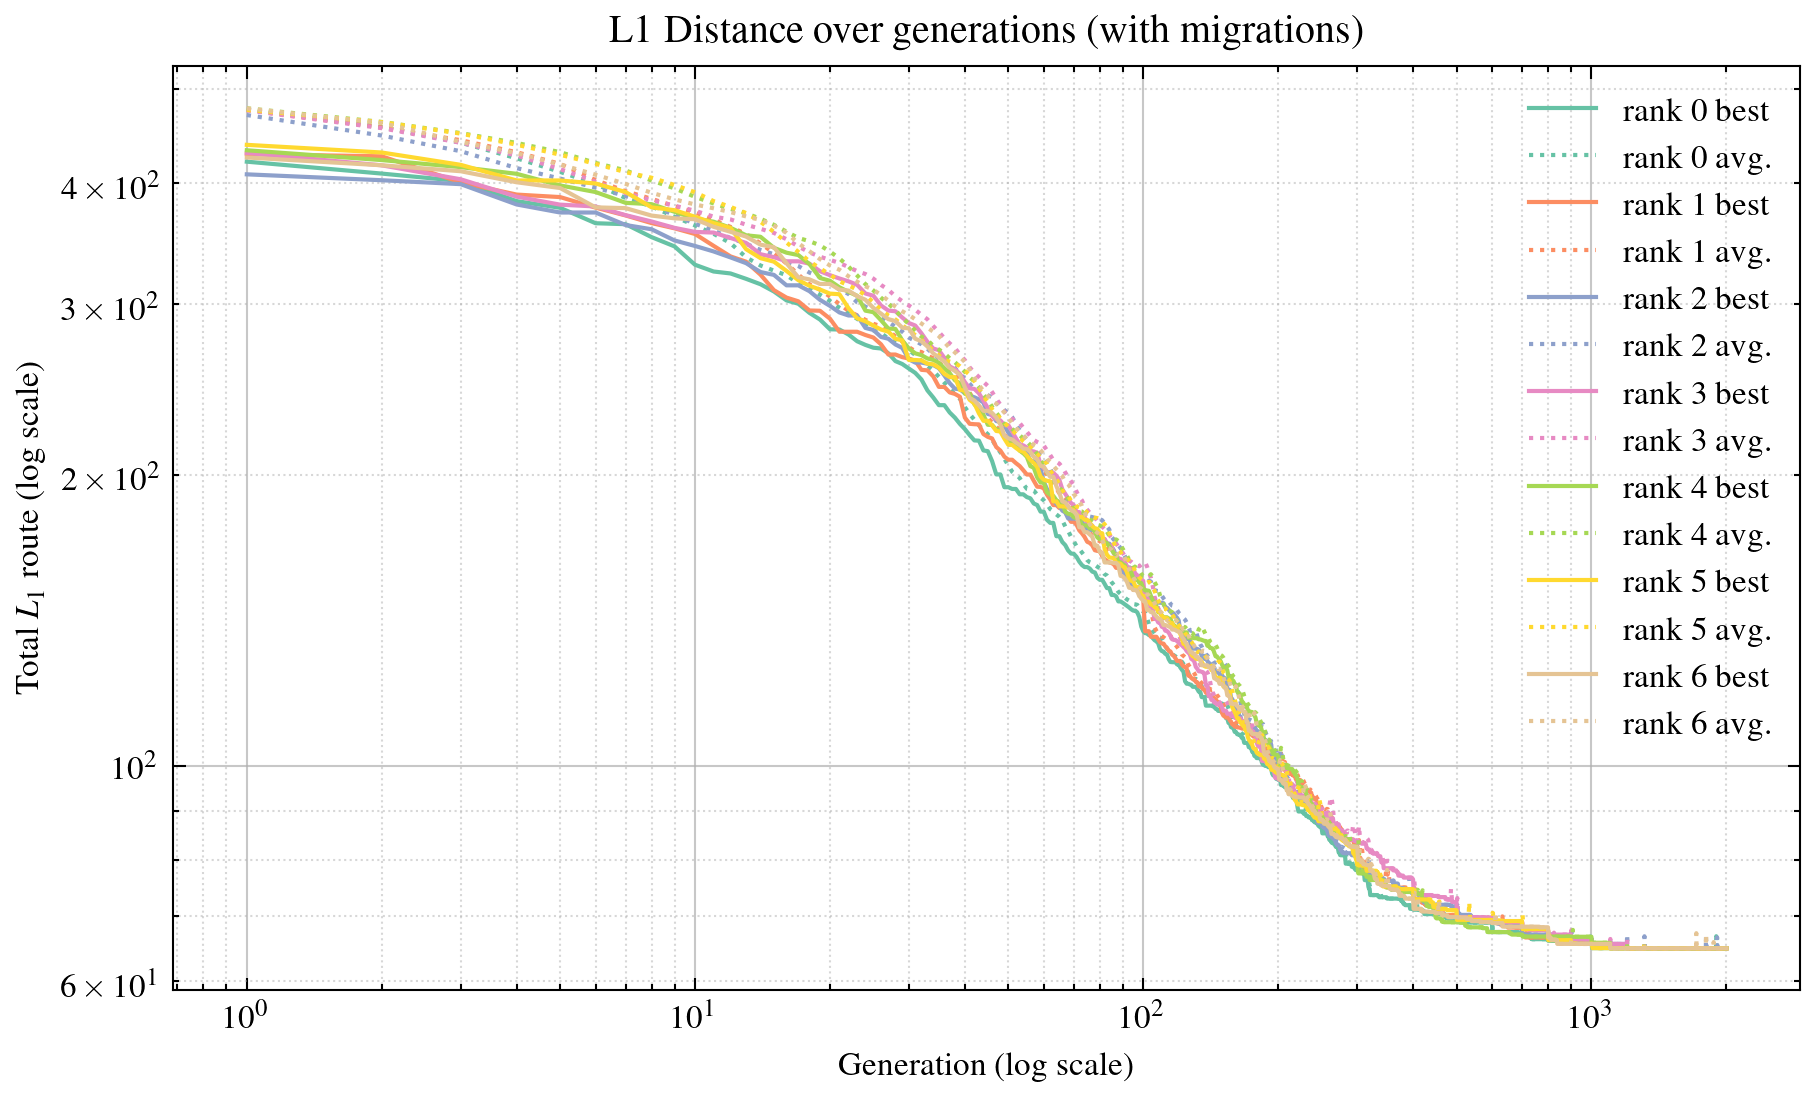

In [3]:
ranks = 7  # number of ranks used

fig = plt.figure(figsize=(7, 4))

min_migration = 1e12  # best route length over all ranks

for rank in range(ranks):
    data = np.loadtxt(f"./data/route_rank{rank}.dat", skiprows=1)

    if data[-1, 0] < min_migration:
        min_migration = data[-1, 0]

    x = np.arange(len(data)) + 1

    (line,) = plt.plot(x, data[:, 0], label=f"rank {rank} best")
    plt.plot(x, data[:, 1], label=f"rank {rank} avg.", ls=":", color=line.get_color())

# style
plt.legend()
plt.grid(which="major", alpha=0.7)
plt.grid(which="minor", alpha=0.5, ls=":")

plt.title("L1 Distance over generations (with migrations)")
plt.xlabel("Generation (log scale)")
plt.ylabel(r"Total $L_1$ route (log scale)")

plt.xscale("log")
plt.yscale("log")

plt.show()

If we add the migrations to the simulation we can see that for a large number of generations the length of the best path converges to one unique value.

We can confront the best result for both simulations (with and without migrations), by just getting the minimum path length:

In [4]:
print(f"Best route (over all ranks) without migrations: {min_no_migration:.3f}")
print(f"Best route (over all ranks) with migrations: {min_migration:.3f}")

Best route (over all ranks) without migrations: 66.383
Best route (over all ranks) with migrations: 64.892


We can see that the genetic algorithm improved with migrations achieved a better result than just running the genetic algorithm multiple times without migrations. In conclusion we can say that parallelization allows us to speed up part of the program, but it also allows the use of completley new algorithms which are not possible to implement in non-parallel computations.

In [5]:
def make_visualization():
    names = np.loadtxt(f"./prov_ita.txt", dtype=str, delimiter=",")

    data = np.loadtxt(f"./cap_prov_ita.dat")
    x_coords = data[:, 0]
    y_coords = data[:, 1]

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot cities
    ax.scatter(x_coords, y_coords, s=10, label="Cities", c="k", zorder=3)

    # Add city labels
    texts = []
    for uid, x, y in zip(names, x_coords, y_coords):
        texts.append(ax.text(x, y, str(uid), fontsize=7, alpha=0.7))

    adjust_text(
        texts,
        arrowprops=None,
        min_arrow_len=50,
        force_points=(2, 2),
        force_explode=(1, 2),
        force_pull=(1, 1),
    )

    # Create a mapping from uid to coordinates
    uid_to_coords = {
        uid: (x, y) for uid, x, y in zip(range(1, len(names) + 1), x_coords, y_coords)
    }

    ranks = 7  # number of ranks used
    for rank in range(ranks):
        # Load the best route
        route = np.loadtxt(f"./data/best_string_rank{rank}.dat", dtype=int)

        # Plot the final route for this rank
        final_route = route[-1]
        coords = np.array([uid_to_coords[uid] for uid in final_route])

        ax.plot(
            coords[:, 0],
            coords[:, 1],
            linewidth=1.5,
            alpha=0.4,
            label=f"Rank {rank}",
            zorder=2,
        )

    # Styling
    ax.set_aspect("equal")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Italian Provinces - Final Routes")

    ax.grid(True)
    ax.legend()

    plt.show()

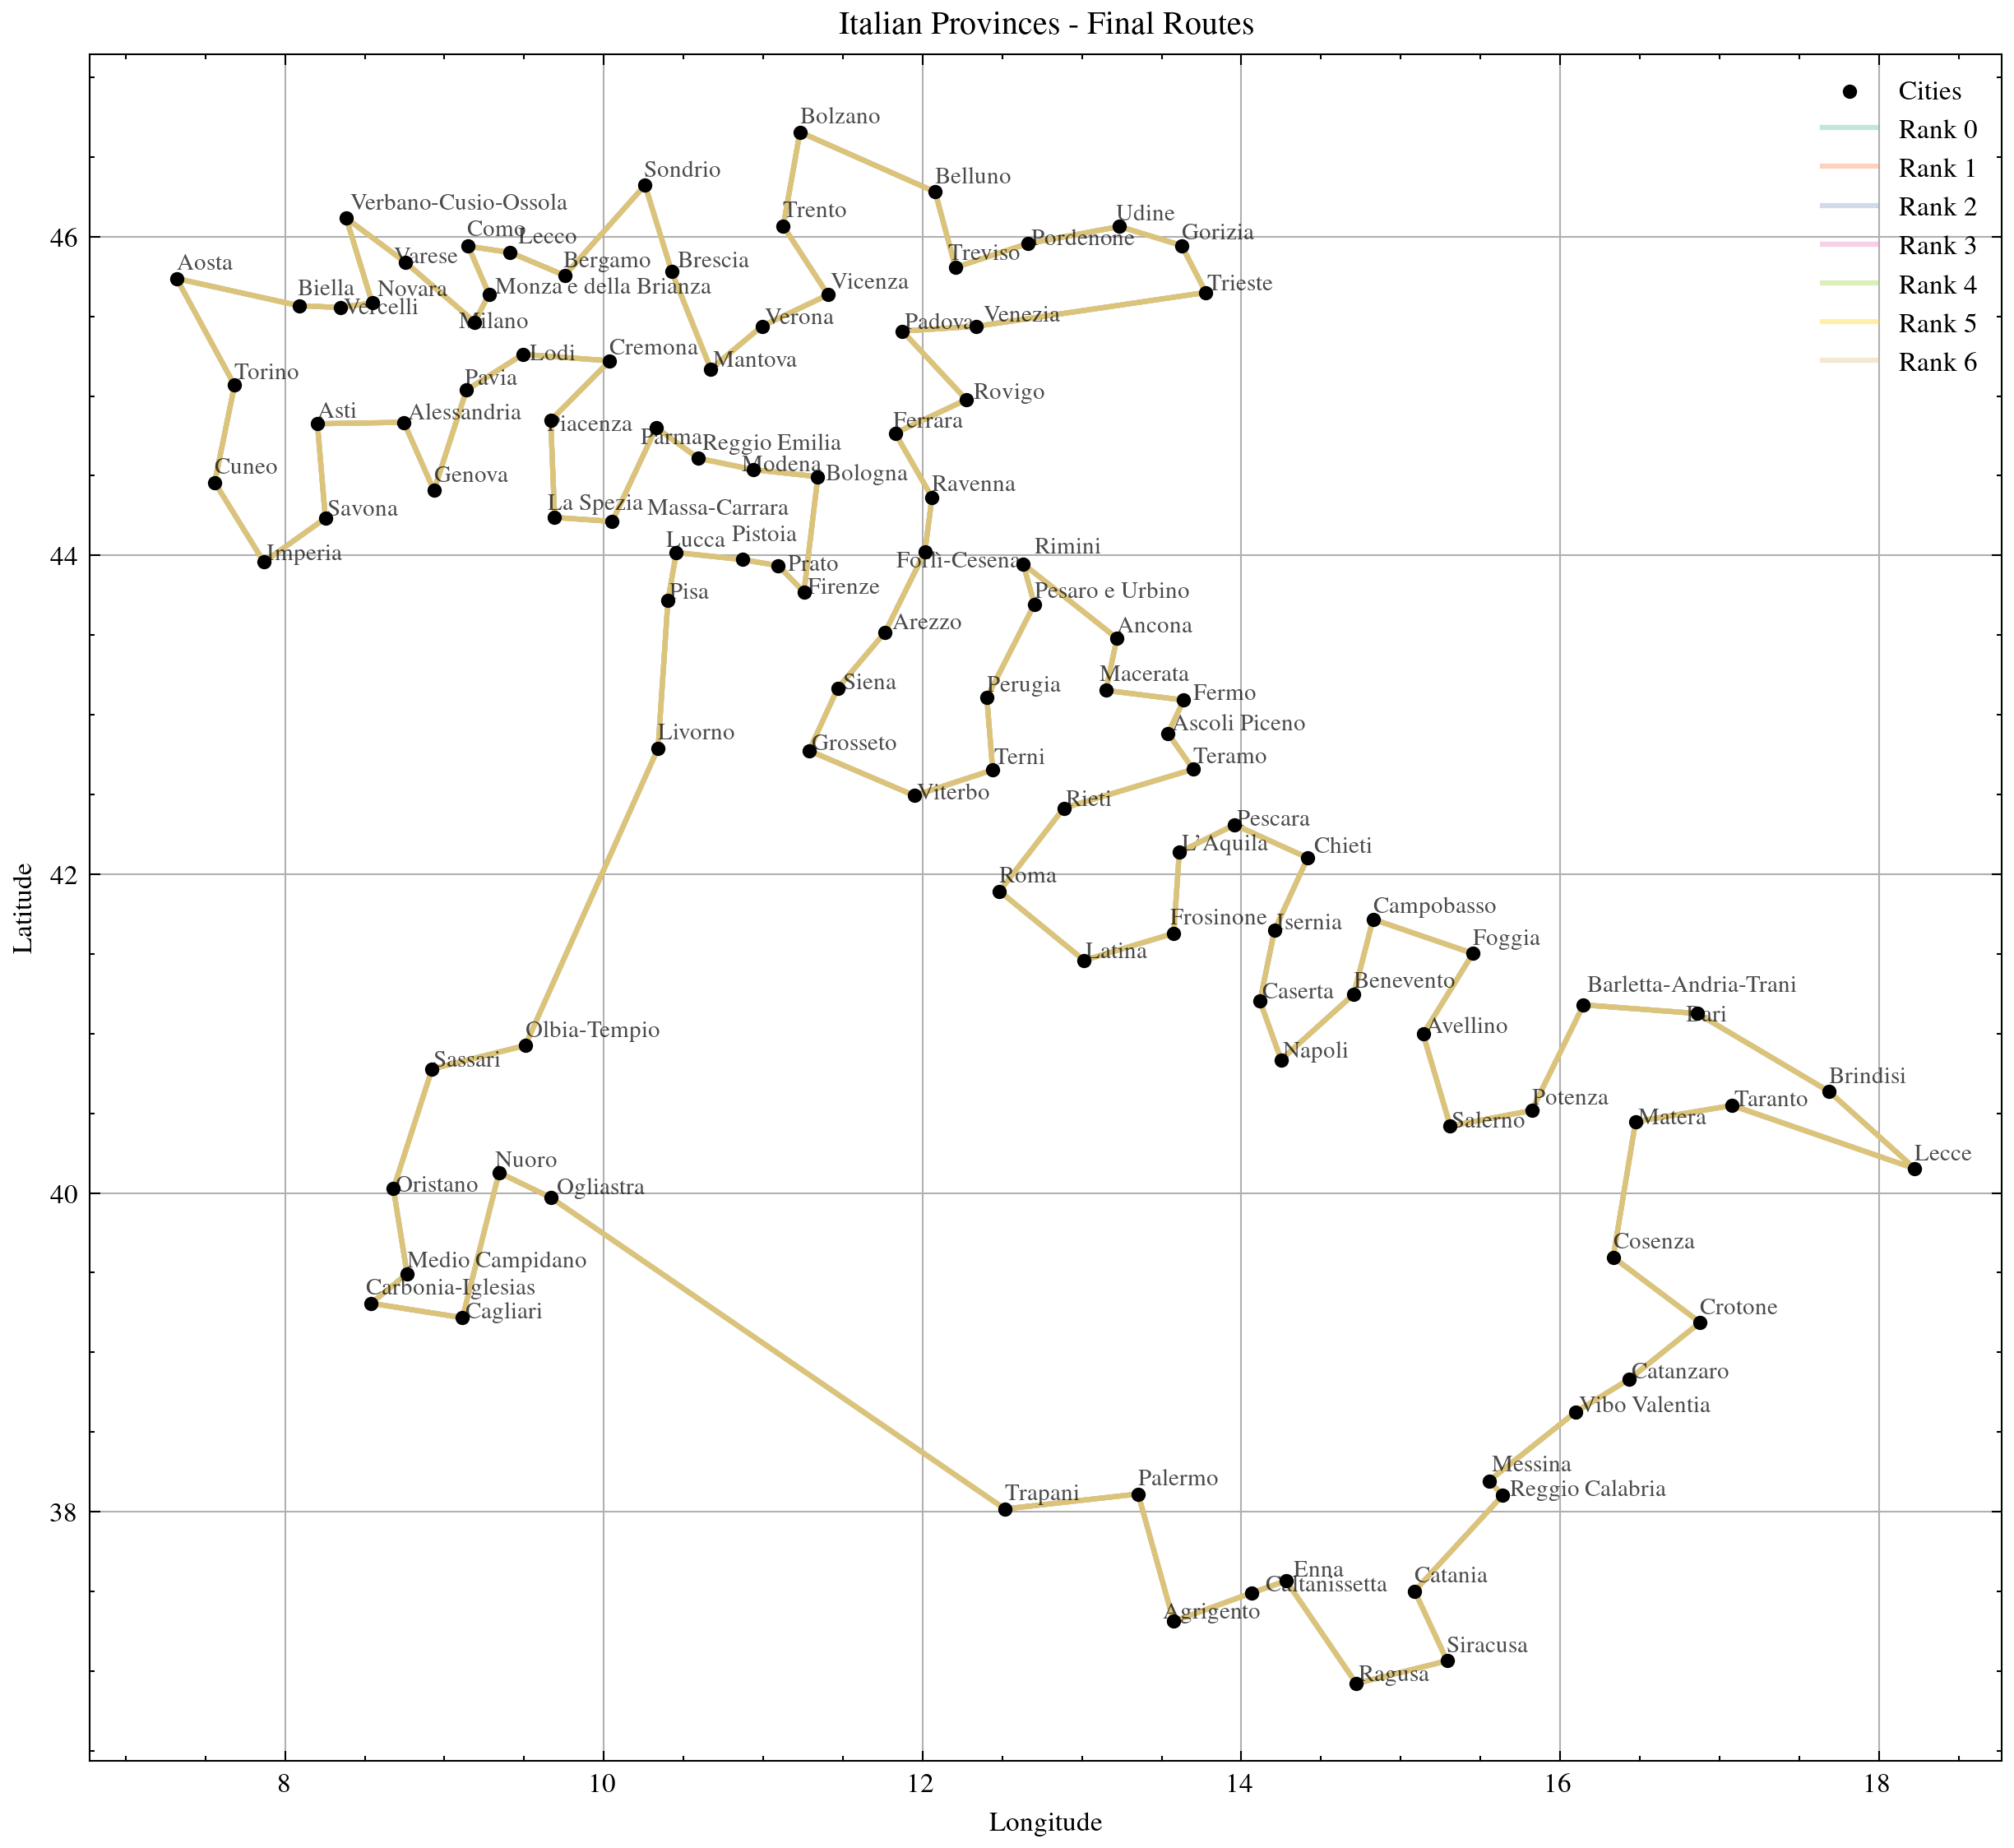

In [6]:
make_visualization()

Above is shown the map used for the simulations with the best path of each rank for the simulation with migrations, as we can see all ranks converge to the same path.